# Phase 2 — Ground-Truth Collapse Definition

This notebook creates objective collapse labels for each equity factor using the
pre-registered rolling-Sharpe rule.

A collapse begins when the trailing 252-trading-day annualized Sharpe ratio falls
more than two standard deviations below its prior five-year reference mean for
at least five consecutive trading days.

Important constraints:

- All calculations are trailing and causal.
- No centered rolling windows are used.
- The five-year reference distribution is shifted by one trading day.
- Collapse dates are generated mechanically rather than selected from charts.
- No early-warning diagnostics are constructed in this notebook.

In [30]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(
    "/content/drive/MyDrive/When_Do_Factor_Premia_Break"
)

PROCESSED = ROOT / "data" / "processed"
RESULTS = ROOT / "data" / "results"

RESULTS.mkdir(parents=True, exist_ok=True)

FACTOR_INPUT = PROCESSED / "factor_returns_daily.parquet"

print("Factor input:", FACTOR_INPUT)
print("Results folder:", RESULTS)

factors = pd.read_parquet(FACTOR_INPUT)

print("Shape:", factors.shape)
print("Columns:", factors.columns.tolist())
print("Date range:", factors.index.min(), "to", factors.index.max())

factors.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Factor input: /content/drive/MyDrive/When_Do_Factor_Premia_Break/data/processed/factor_returns_daily.parquet
Results folder: /content/drive/MyDrive/When_Do_Factor_Premia_Break/data/results
Shape: (15833, 7)
Columns: ['MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM', 'RF']
Date range: 1963-07-01 00:00:00 to 2026-05-29 00:00:00


,MKT_RF,SMB,HML,RMW,CMA,MOM,RF
date,,,,,,,
1963-07-01,-0.0067,0.0000,-0.0034,-0.0001,0.0016,-0.0024,0.0001
1963-07-02,0.0079,-0.0026,0.0026,-0.0007,-0.0020,0.0044,0.0001
1963-07-03,0.0063,-0.0017,-0.0009,0.0018,-0.0034,0.0038,0.0001
1963-07-05,0.0040,0.0008,-0.0027,0.0009,-0.0034,0.0006,0.0001
1963-07-08,-0.0063,0.0004,-0.0018,-0.0029,0.0014,-0.0045,0.0001


In [31]:
FACTOR_COLUMNS = [
    "MKT_RF",
    "SMB",
    "HML",
    "RMW",
    "CMA",
    "MOM",
]

assert isinstance(factors.index, pd.DatetimeIndex)
assert factors.index.is_unique
assert factors.index.is_monotonic_increasing
assert set(FACTOR_COLUMNS).issubset(factors.columns)
assert not factors[FACTOR_COLUMNS].isna().any().any()

print("✓ Factor dataset passed validation")

unit_check = pd.DataFrame(
    {
        "minimum": factors[FACTOR_COLUMNS].min(),
        "maximum": factors[FACTOR_COLUMNS].max(),
        "median_absolute_return": factors[
            FACTOR_COLUMNS
        ].abs().median(),
    }
)

unit_check

✓ Factor dataset passed validation


,minimum,maximum,median_absolute_return
MKT_RF,-0.1744,0.1136,0.0047
SMB,-0.1115,0.0608,0.0029
HML,-0.0503,0.0673,0.0025
RMW,-0.0297,0.0457,0.0019
CMA,-0.0531,0.0248,0.0019
MOM,-0.1439,0.0712,0.0031


In [32]:
TRADING_DAYS_PER_YEAR = 252
SHARPE_WINDOW = 252
REFERENCE_WINDOW = 1260
COLLAPSE_Z_THRESHOLD = -2.0
MIN_CONSECUTIVE_DAYS = 5

COLLAPSE_PARAMETERS = {
    "trading_days_per_year": TRADING_DAYS_PER_YEAR,
    "sharpe_window": SHARPE_WINDOW,
    "reference_window": REFERENCE_WINDOW,
    "collapse_z_threshold": COLLAPSE_Z_THRESHOLD,
    "minimum_consecutive_days": MIN_CONSECUTIVE_DAYS,
    "reference_shift_days": 1,
}

COLLAPSE_PARAMETERS

{'trading_days_per_year': 252,
 'sharpe_window': 252,
 'reference_window': 1260,
 'collapse_z_threshold': -2.0,
 'minimum_consecutive_days': 5,
 'reference_shift_days': 1}

In [33]:
def trailing_annualized_sharpe(
    returns: pd.Series,
    window: int = 252,
    annualization: int = 252,
) -> pd.Series:
    """
    Calculate a trailing annualized Sharpe ratio.

    The value at date t uses returns from t-window+1 through t only.
    """
    rolling_mean = returns.rolling(
        window=window,
        min_periods=window,
    ).mean()

    rolling_std = returns.rolling(
        window=window,
        min_periods=window,
    ).std(ddof=1)

    sharpe = (
        np.sqrt(annualization)
        * rolling_mean
        / rolling_std
    )

    # Avoid infinite values if a window has zero variance.
    sharpe = sharpe.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    return sharpe

rolling_sharpe = pd.DataFrame(
    {
        factor: trailing_annualized_sharpe(
            factors[factor],
            window=SHARPE_WINDOW,
            annualization=TRADING_DAYS_PER_YEAR,
        )
        for factor in FACTOR_COLUMNS
    },
    index=factors.index,
)

rolling_sharpe.head(260).tail()

,MKT_RF,SMB,HML,RMW,CMA,MOM
date,,,,,,
1964-07-07,1.989772,-1.567517,2.945675,-0.189133,0.700809,1.252953
1964-07-08,2.084362,-1.570244,3.018653,-0.121777,0.703211,1.340341
1964-07-09,2.044547,-1.484936,2.969134,-0.229061,0.789694,1.205799
1964-07-10,2.094481,-1.530001,3.054811,-0.200600,0.869387,1.203947
1964-07-13,2.107040,-1.552422,3.155582,-0.118452,0.822304,1.205928


In [34]:
def trailing_reference_statistics(
    statistic: pd.Series,
    window: int = 1260,
) -> tuple[pd.Series, pd.Series]:
    """
    Calculate causal reference mean and standard deviation.

    At date t, the reference distribution uses only values dated t-1
    and earlier.
    """
    prior_statistic = statistic.shift(1)

    reference_mean = prior_statistic.rolling(
        window=window,
        min_periods=window,
    ).mean()

    reference_std = prior_statistic.rolling(
        window=window,
        min_periods=window,
    ).std(ddof=1)

    return reference_mean, reference_std

reference_mean = pd.DataFrame(
    index=rolling_sharpe.index,
    columns=FACTOR_COLUMNS,
    dtype=float,
)

reference_std = pd.DataFrame(
    index=rolling_sharpe.index,
    columns=FACTOR_COLUMNS,
    dtype=float,
)

for factor in FACTOR_COLUMNS:
    mean_series, std_series = (
        trailing_reference_statistics(
            rolling_sharpe[factor],
            window=REFERENCE_WINDOW,
        )
    )

    reference_mean[factor] = mean_series
    reference_std[factor] = std_series



In [35]:
collapse_boundary = (
    reference_mean
    + COLLAPSE_Z_THRESHOLD * reference_std
)

raw_collapse_condition = (
    rolling_sharpe < collapse_boundary
)

raw_collapse_condition = (
    raw_collapse_condition
    & rolling_sharpe.notna()
    & collapse_boundary.notna()
)

reference_mean - 2 * reference_std

availability = pd.DataFrame(
    {
        "first_return": factors[
            FACTOR_COLUMNS
        ].apply(lambda x: x.first_valid_index()),

        "first_sharpe": rolling_sharpe.apply(
            lambda x: x.first_valid_index()
        ),

        "first_boundary": collapse_boundary.apply(
            lambda x: x.first_valid_index()
        ),
    }
)

availability

,first_return,first_sharpe,first_boundary
MKT_RF,1963-07-01,1964-06-30,1969-08-12
SMB,1963-07-01,1964-06-30,1969-08-12
HML,1963-07-01,1964-06-30,1969-08-12
RMW,1963-07-01,1964-06-30,1969-08-12
CMA,1963-07-01,1964-06-30,1969-08-12
MOM,1963-07-01,1964-06-30,1969-08-12


In [36]:
def consecutive_true_run_lengths(
    condition: pd.Series,
) -> pd.Series:
    """
    Return the length of the current consecutive True run at each date.

    False dates receive a run length of zero.
    """
    condition = condition.fillna(False).astype(bool)

    groups = (~condition).cumsum()

    run_lengths = (
        condition.astype(int)
        .groupby(groups)
        .cumsum()
    )

    return run_lengths.astype(int)

#TEST

test_condition = pd.Series(
    [False, True, True, True, False, True, True]
)

expected = pd.Series(
    [0, 1, 2, 3, 0, 1, 2]
)

actual = consecutive_true_run_lengths(test_condition)

pd.testing.assert_series_equal(
    actual.reset_index(drop=True),
    expected,
)

print("✓ Run-length helper passed synthetic test")

collapse_run_length = pd.DataFrame(
    {
        factor: consecutive_true_run_lengths(
            raw_collapse_condition[factor]
        )
        for factor in FACTOR_COLUMNS
    },
    index=factors.index,
)

✓ Run-length helper passed synthetic test


In [37]:
def build_confirmed_collapse_labels(
    condition: pd.Series,
    entry_confirmation_days: int = 5,
    exit_confirmation_days: int = 5,
) -> pd.Series:
    """
    Construct historically confirmed collapse labels.

    Entry:
        The below-boundary condition must persist for the required
        number of consecutive days. Once confirmed, the episode is
        labeled retroactively from the first below-boundary day.

    Exit:
        The condition must remain false for the required number of
        consecutive days. Once confirmed, the collapse ends on the
        day before the recovery run began.

    This function creates historical ground-truth labels. It is not
    intended to represent a live real-time signal.
    """
    condition = condition.fillna(False).astype(bool)

    labels = pd.Series(
        False,
        index=condition.index,
        dtype=bool,
    )

    in_collapse = False
    below_run_start = None
    below_run_length = 0
    above_run_start = None
    above_run_length = 0

    for position, is_below in enumerate(condition.to_numpy()):
        current_date = condition.index[position]

        if not in_collapse:
            if is_below:
                if below_run_length == 0:
                    below_run_start = current_date

                below_run_length += 1

                if below_run_length >= entry_confirmation_days:
                    in_collapse = True

                    labels.loc[
                        below_run_start:current_date
                    ] = True

                    above_run_start = None
                    above_run_length = 0
            else:
                below_run_start = None
                below_run_length = 0

        else:
            if is_below:
                labels.loc[current_date] = True

                above_run_start = None
                above_run_length = 0
            else:
                if above_run_length == 0:
                    above_run_start = current_date

                above_run_length += 1

                if above_run_length >= exit_confirmation_days:
                    labels.loc[
                          above_run_start:current_date
                    ] = False

                    in_collapse = False

                    below_run_start = None
                    below_run_length = 0
                    above_run_start = None
                    above_run_length = 0
                else:
                    labels.loc[current_date] = True

    # If the sample ends during an unconfirmed entry run, it remains
    # unlabeled. If it ends during a confirmed collapse or an
    # unconfirmed recovery, the episode remains active through the end.
    return labels

In [38]:
test_index = pd.date_range(
    "2020-01-01",
    periods=20,
    freq="B",
)

# Five below-threshold days establish a collapse.
# A two-day interruption should not end it.
# A final five-day recovery should end it.
test_condition = pd.Series(
    [
        False, False,
        True, True, True, True, True,
        False, False,
        True, True, True,
        False, False, False, False, False,
        False, False, False,
    ],
    index=test_index,
)

test_labels = build_confirmed_collapse_labels(
    test_condition,
    entry_confirmation_days=5,
    exit_confirmation_days=5,
)

expected_labels = pd.Series(
    [
        False, False,
        True, True, True, True, True,
        True, True,
        True, True, True,
        False, False, False, False, False,
        False, False, False,
    ],
    index=test_index,
)

pd.testing.assert_series_equal(
    test_labels,
    expected_labels,
)

print("✓ Entry and exit confirmation test passed")

short_decline = pd.Series(
    [False, True, True, True, True, False, False],
    index=pd.date_range(
        "2021-01-01",
        periods=7,
        freq="B",
    ),
)

short_labels = build_confirmed_collapse_labels(
    short_decline,
    entry_confirmation_days=5,
    exit_confirmation_days=5,
)

assert not short_labels.any()

print("✓ Unconfirmed four-day decline remains unlabeled")

collapse_label = pd.DataFrame(
    {
        factor: build_confirmed_collapse_labels(
            raw_collapse_condition[factor],
            entry_confirmation_days=MIN_CONSECUTIVE_DAYS,
            exit_confirmation_days=MIN_CONSECUTIVE_DAYS,
        )
        for factor in FACTOR_COLUMNS
    },
    index=factors.index,
)

✓ Entry and exit confirmation test passed
✓ Unconfirmed four-day decline remains unlabeled


In [39]:
def extract_boolean_episodes(
    labels: pd.Series,
    factor_name: str,
) -> pd.DataFrame:
    """
    Convert a Boolean event series into one row per continuous episode.
    """
    labels = labels.fillna(False).astype(bool)

    starts = labels & ~labels.shift(
        1,
        fill_value=False,
    )

    ends = labels & ~labels.shift(
        -1,
        fill_value=False,
    )

    start_dates = labels.index[starts]
    end_dates = labels.index[ends]

    if len(start_dates) != len(end_dates):
        raise ValueError(
            f"Episode boundary mismatch for {factor_name}"
        )

    episodes = pd.DataFrame(
        {
            "factor": factor_name,
            "collapse_start": start_dates,
            "collapse_end": end_dates,
        }
    )

    if episodes.empty:
        episodes["duration_trading_days"] = pd.Series(
            dtype=int
        )
        return episodes

    index_positions = pd.Series(
        np.arange(len(labels)),
        index=labels.index,
    )

    episodes["duration_trading_days"] = [
        int(
            index_positions.loc[end]
            - index_positions.loc[start]
            + 1
        )
        for start, end in zip(
            episodes["collapse_start"],
            episodes["collapse_end"],
        )
    ]

    return episodes

episode_tables = [
    extract_boolean_episodes(
        collapse_label[factor],
        factor_name=factor,
    )
    for factor in FACTOR_COLUMNS
]

collapse_events = pd.concat(
    episode_tables,
    ignore_index=True,
)

collapse_events = collapse_events.sort_values(
    ["collapse_start", "factor"]
).reset_index(drop=True)

collapse_events

,factor,collapse_start,collapse_end,duration_trading_days
0,SMB,1969-08-12,1969-08-20,7
1,SMB,1969-11-21,1970-07-23,169
2,MKT_RF,1969-11-24,1969-12-31,26
3,HML,1969-12-10,1970-01-22,30
4,MKT_RF,1970-01-26,1970-02-18,18
...,...,...,...,...
82,CMA,2023-12-27,2024-01-22,17
83,RMW,2025-06-20,2025-07-09,13
84,RMW,2025-08-04,2025-09-10,27
85,RMW,2025-09-18,2026-01-28,91


In [40]:
def add_event_statistics(
    events: pd.DataFrame,
    sharpe: pd.DataFrame,
    boundary: pd.DataFrame,
) -> pd.DataFrame:
    """Add descriptive statistics to the event table."""
    output = events.copy()

    minimum_sharpes = []
    minimum_gaps = []
    start_sharpes = []
    start_boundaries = []

    for row in output.itertuples(index=False):
        factor = row.factor
        start = row.collapse_start
        end = row.collapse_end

        event_sharpe = sharpe.loc[start:end, factor]
        event_boundary = boundary.loc[start:end, factor]

        minimum_sharpes.append(event_sharpe.min())
        minimum_gaps.append(
            (event_sharpe - event_boundary).min()
        )
        start_sharpes.append(sharpe.loc[start, factor])
        start_boundaries.append(
            boundary.loc[start, factor]
        )

    output["start_sharpe"] = start_sharpes
    output["start_boundary"] = start_boundaries
    output["minimum_event_sharpe"] = minimum_sharpes
    output["minimum_sharpe_minus_boundary"] = minimum_gaps

    return output

collapse_events = add_event_statistics(
    collapse_events,
    rolling_sharpe,
    collapse_boundary,
)

collapse_events

,factor,collapse_start,collapse_end,duration_trading_days,start_sharpe,start_boundary,minimum_event_sharpe,minimum_sharpe_minus_boundary
0,SMB,1969-08-12,1969-08-20,7,-1.487049,-1.401711,-1.566801,-0.165788
1,SMB,1969-11-21,1970-07-23,169,-1.462847,-1.401972,-4.518267,-1.795078
2,MKT_RF,1969-11-24,1969-12-31,26,-1.597490,-1.502104,-2.291773,-0.674384
3,HML,1969-12-10,1970-01-22,30,-1.619492,-1.618892,-2.081929,-0.355327
4,MKT_RF,1970-01-26,1970-02-18,18,-1.856079,-1.745830,-2.234301,-0.463295
...,...,...,...,...,...,...,...,...
82,CMA,2023-12-27,2024-01-22,17,-2.064984,-2.002739,-2.362055,-0.314367
83,RMW,2025-06-20,2025-07-09,13,-0.628504,-0.606542,-0.718430,-0.107809
84,RMW,2025-08-04,2025-09-10,27,-0.663889,-0.657840,-0.861616,-0.198880
85,RMW,2025-09-18,2026-01-28,91,-0.929304,-0.754581,-1.518470,-0.694978


In [49]:
assert collapse_label.index.equals(factors.index)
assert collapse_label.columns.tolist() == FACTOR_COLUMNS
assert collapse_label.dtypes.eq(bool).all()

assert (
    collapse_events["duration_trading_days"]
    >= MIN_CONSECUTIVE_DAYS
).all()


def longest_false_run_inside_labels(
    labels: pd.Series,
    raw_condition: pd.Series,
) -> int:
    """
    Find the longest run of above-boundary days that remains inside
    a confirmed collapse episode.
    """
    interruption = (
        labels.fillna(False).astype(bool)
        & ~raw_condition.fillna(False).astype(bool)
    )

    if not interruption.any():
        return 0

    group_id = interruption.ne(interruption.shift()).cumsum()

    run_lengths = (
        interruption.groupby(group_id)
        .sum()
    )

    return int(run_lengths.max())


for factor in FACTOR_COLUMNS:
    longest_interruption = longest_false_run_inside_labels(
        collapse_label[factor],
        raw_collapse_condition[factor],
    )

    assert longest_interruption < MIN_CONSECUTIVE_DAYS, (
        f"{factor}: found an above-boundary interruption lasting "
        f"{longest_interruption} days inside a collapse"
    )
for row in collapse_events.itertuples(index=False):
    initial_window = raw_collapse_condition.loc[
        row.collapse_start:,
        row.factor,
    ].iloc[:MIN_CONSECUTIVE_DAYS]

    assert len(initial_window) == MIN_CONSECUTIVE_DAYS
    assert initial_window.all(), (
        f"{row.factor}: collapse beginning "
        f"{row.collapse_start.date()} was not supported by "
        f"{MIN_CONSECUTIVE_DAYS} initial below-boundary days"
    )
assert (
    collapse_events["start_sharpe"]
    < collapse_events["start_boundary"]
).all()

for row in collapse_events.itertuples(index=False):
    expected_duration = len(
        factors.loc[
            row.collapse_start:row.collapse_end
        ]
    )

    assert row.duration_trading_days == expected_duration, (
        f"{row.factor}: duration mismatch for event beginning "
        f"{row.collapse_start.date()}"
    )

print("✓ Every event duration matches the trading-date index")
print("✓ Every collapse begins below its boundary")
print("✓ Every collapse passed the entry-confirmation test")
print("✓ Collapse labels passed structural validation")

✓ Every event duration matches the trading-date index
✓ Every collapse begins below its boundary
✓ Every collapse passed the entry-confirmation test
✓ Collapse labels passed structural validation


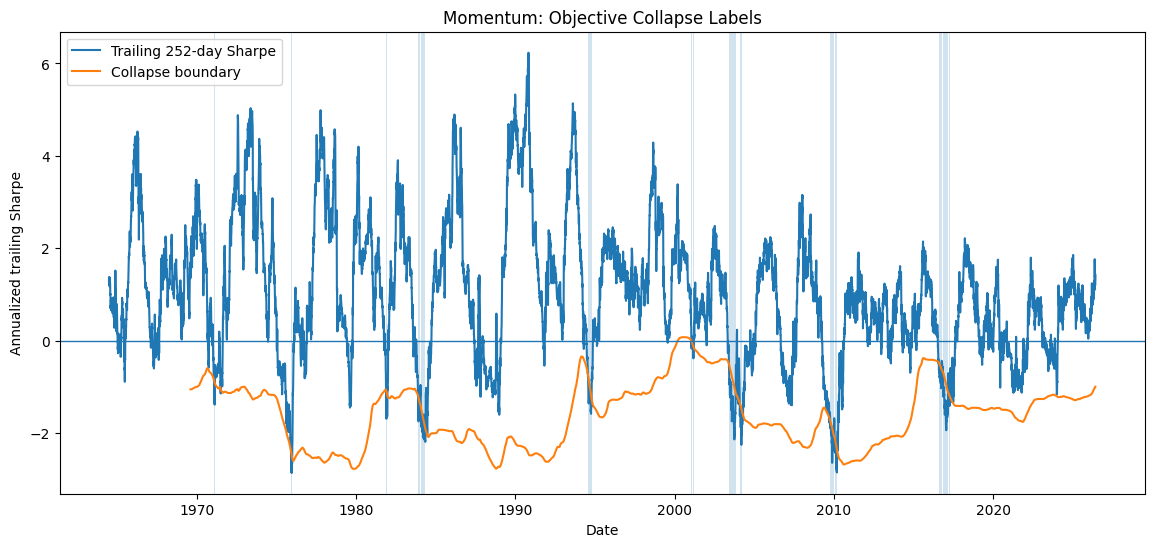

In [42]:
factor = "MOM"

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    rolling_sharpe.index,
    rolling_sharpe[factor],
    label="Trailing 252-day Sharpe",
)

ax.plot(
    collapse_boundary.index,
    collapse_boundary[factor],
    label="Collapse boundary",
)

for row in collapse_events.query(
    "factor == @factor"
).itertuples():
    ax.axvspan(
        row.collapse_start,
        row.collapse_end,
        alpha=0.2,
    )

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title(
    "Momentum: Objective Collapse Labels"
)
ax.set_xlabel("Date")
ax.set_ylabel("Annualized trailing Sharpe")
ax.legend()

plt.show()



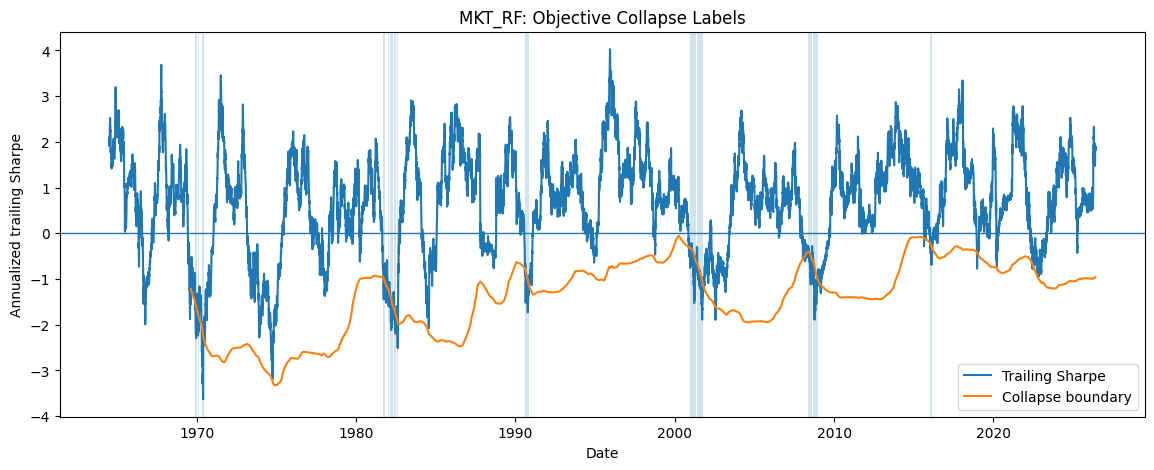

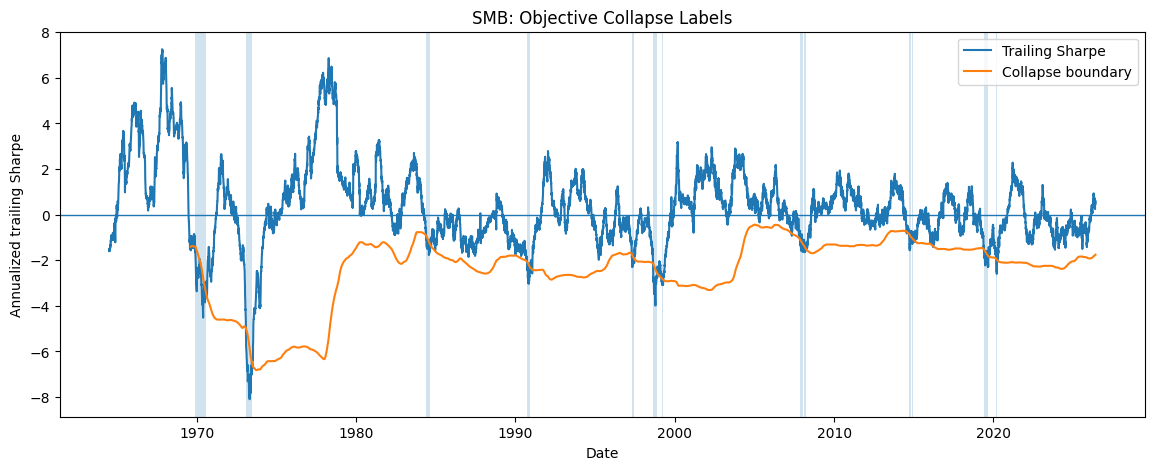

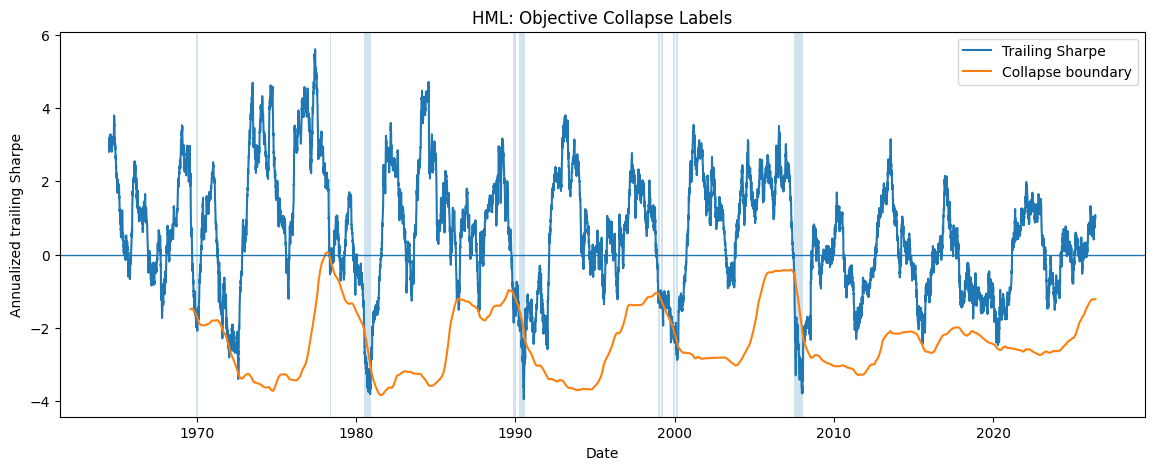

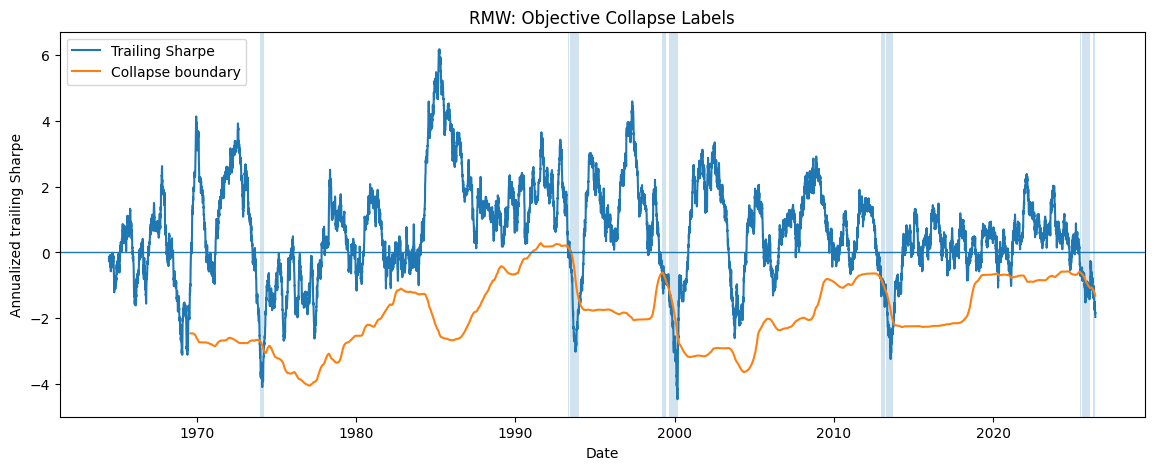

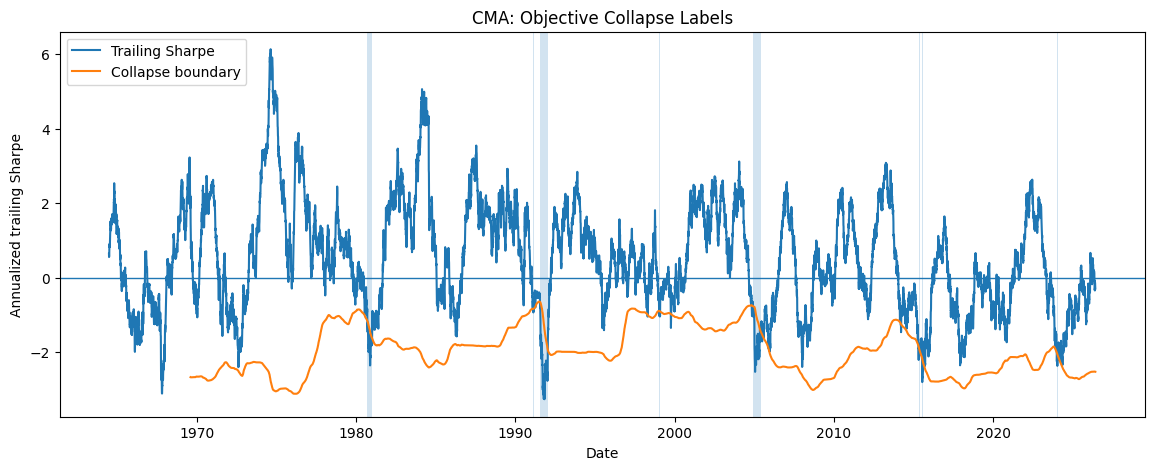

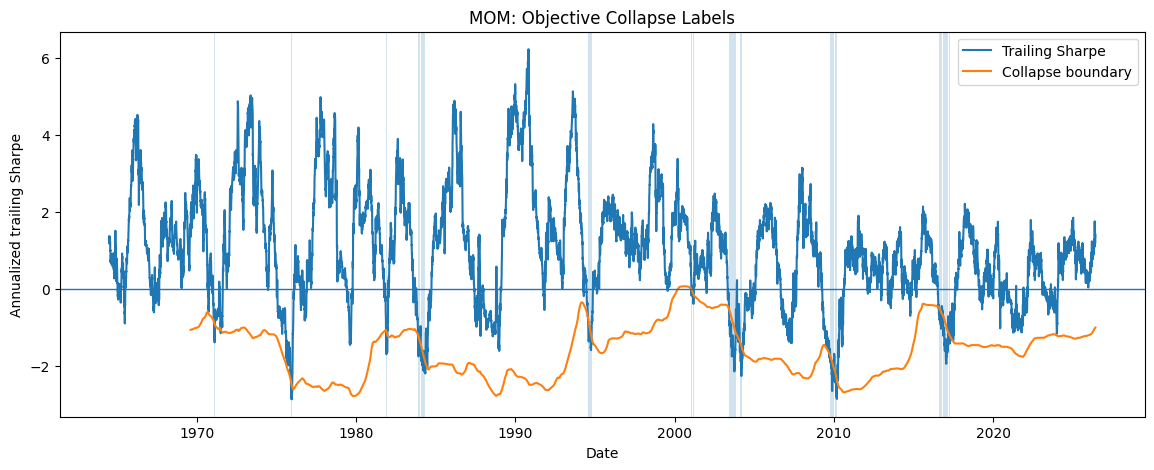

In [43]:
for factor in FACTOR_COLUMNS:
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(
        rolling_sharpe.index,
        rolling_sharpe[factor],
        label="Trailing Sharpe",
    )

    ax.plot(
        collapse_boundary.index,
        collapse_boundary[factor],
        label="Collapse boundary",
    )

    factor_events = collapse_events.query(
        "factor == @factor"
    )

    for row in factor_events.itertuples():
        ax.axvspan(
            row.collapse_start,
            row.collapse_end,
            alpha=0.2,
        )

    ax.axhline(0, linewidth=1)

    ax.set_title(
        f"{factor}: Objective Collapse Labels"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Annualized trailing Sharpe")
    ax.legend()

    plt.show()

In [44]:
collapse_statistics = pd.concat(
    {
        "rolling_sharpe": rolling_sharpe,
        "reference_mean": reference_mean,
        "reference_std": reference_std,
        "collapse_boundary": collapse_boundary,
        "raw_condition": raw_collapse_condition.astype(int),
        "confirmed_label": collapse_label.astype(int),
    },
    axis=1,
)

COLLAPSE_STATS_OUTPUT = (
    RESULTS / "collapse_statistics_daily.parquet"
)

collapse_statistics.to_parquet(
    COLLAPSE_STATS_OUTPUT
)

print("Saved:", COLLAPSE_STATS_OUTPUT)

COLLAPSE_EVENTS_OUTPUT = (
    RESULTS / "collapse_events.csv"
)

collapse_events.to_csv(
    COLLAPSE_EVENTS_OUTPUT,
    index=False,
)

print("Saved:", COLLAPSE_EVENTS_OUTPUT)

import json

COLLAPSE_CONFIG_OUTPUT = (
    RESULTS / "collapse_definition_parameters.json"
)

with open(
    COLLAPSE_CONFIG_OUTPUT,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        COLLAPSE_PARAMETERS,
        file,
        indent=2,
        sort_keys=True,
    )

print("Saved:", COLLAPSE_CONFIG_OUTPUT)

Saved: /content/drive/MyDrive/When_Do_Factor_Premia_Break/data/results/collapse_statistics_daily.parquet
Saved: /content/drive/MyDrive/When_Do_Factor_Premia_Break/data/results/collapse_events.csv
Saved: /content/drive/MyDrive/When_Do_Factor_Premia_Break/data/results/collapse_definition_parameters.json


In [45]:
collapse_statistics_reload = pd.read_parquet(
    COLLAPSE_STATS_OUTPUT
)

collapse_events_reload = pd.read_csv(
    COLLAPSE_EVENTS_OUTPUT,
    parse_dates=[
        "collapse_start",
        "collapse_end",
    ],
)

pd.testing.assert_frame_equal(
    collapse_statistics,
    collapse_statistics_reload,
)

pd.testing.assert_frame_equal(
    collapse_events.reset_index(drop=True),
    collapse_events_reload.reset_index(drop=True),
    check_dtype=False,
)

print("✓ Saved collapse outputs reload correctly")

✓ Saved collapse outputs reload correctly


In [46]:
def compute_causal_collapse_inputs(
    returns: pd.Series,
) -> pd.DataFrame:
    """
    Compute the causal continuous inputs to the collapse rule.
    """
    sharpe = trailing_annualized_sharpe(
        returns,
        window=SHARPE_WINDOW,
        annualization=TRADING_DAYS_PER_YEAR,
    )

    ref_mean, ref_std = trailing_reference_statistics(
        sharpe,
        window=REFERENCE_WINDOW,
    )

    boundary = (
        ref_mean
        + COLLAPSE_Z_THRESHOLD * ref_std
    )

    return pd.DataFrame(
        {
            "sharpe": sharpe,
            "reference_mean": ref_mean,
            "reference_std": ref_std,
            "boundary": boundary,
        }
    )

original_returns = factors["MOM"].copy()

cutoff_position = int(
    len(original_returns) * 0.75
)

cutoff_date = original_returns.index[
    cutoff_position
]

altered_returns = original_returns.copy()

altered_returns.loc[
    altered_returns.index > cutoff_date
] = (
    altered_returns.loc[
        altered_returns.index > cutoff_date
    ]
    * -7.0
    + 0.15
)

original_output = compute_causal_collapse_inputs(
    original_returns
)

altered_output = compute_causal_collapse_inputs(
    altered_returns
)

pd.testing.assert_frame_equal(
    original_output.loc[:cutoff_date],
    altered_output.loc[:cutoff_date],
)

print(
    "✓ Future-data alteration did not change "
    f"outputs through {cutoff_date.date()}"
)

✓ Future-data alteration did not change outputs through 2010-09-01


In [47]:
print("=" * 65)
print("GROUND-TRUTH COLLAPSE DEFINITION COMPLETE")
print("=" * 65)

print(
    f"Factors evaluated: {len(FACTOR_COLUMNS)}"
)

print(
    f"Total collapse episodes: "
    f"{len(collapse_events)}"
)

print("\nEvents per factor:")

display(
    collapse_events[
        "factor"
    ].value_counts()
    .reindex(
        FACTOR_COLUMNS,
        fill_value=0,
    )
    .rename("event_count")
    .to_frame()
)

print("\nSaved outputs:")

for path in sorted(RESULTS.iterdir()):
    if path.is_file():
        print(" -", path.name)

GROUND-TRUTH COLLAPSE DEFINITION COMPLETE
Factors evaluated: 6
Total collapse episodes: 87

Events per factor:


,event_count
factor,
MKT_RF,17
SMB,16
HML,14
RMW,13
CMA,11
MOM,16



Saved outputs:
 - collapse_definition_parameters.json
 - collapse_events.csv
 - collapse_statistics_daily.parquet


### Ground-truth validation finding

The pre-registered rolling-Sharpe collapse rule did not identify the onset of the
documented 2008 momentum crash. The first qualifying Momentum collapse near the
development period began on October 7, 2009.

This suggests that the rule identifies sustained post-crash deterioration rather
than the initial crash onset. The specification was retained without adjustment
to avoid post-hoc tuning of the target definition.